In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [ ]:
df=pd.read_csv('../data/train.csv')

In [11]:
df1=df.head()

In [ ]:
df1.to_csv('../data/discovery.csv')

In [13]:
df.head()

,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,Premium,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0
1,1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,Comprehensive,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0
2,2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,Premium,1.0,14.0,NaN,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0
3,3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,Basic,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0
4,4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,Premium,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0


In [ ]:
import pandas as pd
import numpy as np

# Load the full dataset (replace with your actual file)
df = pd.read_csv('../data/train.csv')  # Or your actual full dataset file

print("="*70)
print("STEP 2: ENHANCED RISK CLASSIFICATION")
print("="*70)

# First, let's understand the distributions to set smart thresholds
print("\n1. Understanding Feature Distributions:")
print("\nAge Distribution:")
print(df['Age'].describe())

print("\nAnnual Income Distribution:")
print(df['Annual Income'].describe())

print("\nHealth Score Distribution:")
print(df['Health Score'].describe())

print("\nCredit Score Distribution:")
print(df['Credit Score'].describe())

print("\nPrevious Claims Distribution:")
print(df['Previous Claims'].value_counts())

print("\nVehicle Age Distribution:")
print(df['Vehicle Age'].describe())

print("\nSmoking Status Distribution:")
print(df['Smoking Status'].value_counts())

print("\nExercise Frequency Distribution:")
print(df['Exercise Frequency'].value_counts())

# Define classification function with enhanced criteria
def classify_risk_enhanced(row):
    """
    Enhanced risk classification using multiple factors:
    
    LOW RISK (Score 0-3):
    - Young age (< 30)
    - High income (> 70k)
    - Non-smoker
    - Good health (> 60)
    - Good credit (> 650)
    - No/few previous claims
    - Regular exercise
    
    HIGH RISK (Score 8+):
    - Old age (> 55)
    - Low income (< 30k)
    - Smoker
    - Poor health (< 40)
    - Poor credit (< 400)
    - Multiple previous claims
    - No exercise
    
    MEDIUM RISK: Everything else
    """
    
    # Initialize risk score
    risk_score = 0
    
    # AGE FACTOR (0-2 points)
    age = row['Age']
    if pd.notna(age):
        if age < 30:
            risk_score += 0  # Low risk
        elif age < 50:
            risk_score += 1  # Medium risk
        else:
            risk_score += 2  # High risk (age > 50)
    
    # INCOME FACTOR (0-2 points)
    income = row['Annual Income']
    if pd.notna(income):
        if income > 70000:
            risk_score += 0  # Low risk
        elif income > 35000:
            risk_score += 1  # Medium risk
        else:
            risk_score += 2  # High risk (income < 35k)
    
    # SMOKING STATUS (0-3 points) - Major risk factor!
    smoking = row['Smoking Status']
    if smoking == 'Yes':
        risk_score += 3  # High risk
    elif smoking == 'No':
        risk_score += 0  # Low risk
    
    # HEALTH SCORE (0-2 points)
    health = row['Health Score']
    if pd.notna(health):
        if health > 60:
            risk_score += 0  # Low risk
        elif health > 30:
            risk_score += 1  # Medium risk
        else:
            risk_score += 2  # High risk (health < 30)
    
    # CREDIT SCORE (0-2 points)
    credit = row['Credit Score']
    if pd.notna(credit):
        if credit > 650:
            risk_score += 0  # Low risk
        elif credit > 400:
            risk_score += 1  # Medium risk
        else:
            risk_score += 2  # High risk (credit < 400)
    
    # PREVIOUS CLAIMS (0-2 points)
    claims = row['Previous Claims']
    if pd.notna(claims):
        if claims == 0:
            risk_score += 0  # Low risk
        elif claims <= 2:
            risk_score += 1  # Medium risk
        else:
            risk_score += 2  # High risk (3+ claims)
    
    # VEHICLE AGE (0-1 points)
    vehicle_age = row['Vehicle Age']
    if pd.notna(vehicle_age):
        if vehicle_age > 10:
            risk_score += 1  # Higher risk for old vehicles
    
    # EXERCISE FREQUENCY (0-1 points)
    exercise = row['Exercise Frequency']
    if exercise in ['Daily', 'Weekly']:
        risk_score += 0  # Low risk - active lifestyle
    elif exercise in ['Monthly', 'Rarely']:
        risk_score += 1  # Higher risk - sedentary
    
    # NUMBER OF DEPENDENTS (0-1 points)
    dependents = row['Number of Dependents']
    if pd.notna(dependents):
        if dependents > 3:
            risk_score += 1  # Financial stress indicator
    
    # CLASSIFY BASED ON TOTAL RISK SCORE
    # Maximum possible score: 16 points
    if risk_score <= 3:
        return 0  # LOW RISK
    elif risk_score <= 8:
        return 1  # MEDIUM RISK
    else:
        return 2  # HIGH RISK

# Apply the enhanced classification
print("\n2. Applying Enhanced Risk Classification...")
df['Risk_Class'] = df.apply(classify_risk_enhanced, axis=1)

# Map numeric to labels for readability
risk_labels = {0: 'Low Risk', 1: 'Medium Risk', 2: 'High Risk'}
df['Risk_Label'] = df['Risk_Class'].map(risk_labels)

print("\n3. Risk Class Distribution:")
print(df['Risk_Class'].value_counts().sort_index())
print("\nPercentage Distribution:")
print(df['Risk_Class'].value_counts(normalize=True).sort_index() * 100)

print("\n4. Risk Class Summary Statistics:")
for risk_class in [0, 1, 2]:
    print(f"\n{'='*50}")
    print(f"{risk_labels[risk_class].upper()} - CLASS {risk_class}")
    print(f"{'='*50}")
    
    subset = df[df['Risk_Class'] == risk_class]
    print(f"Count: {len(subset)}")
    
    if len(subset) > 0:
        print(f"\nAverage Profile:")
        print(f"  Age:            {subset['Age'].mean():.1f} years")
        print(f"  Annual Income:  ${subset['Annual Income'].mean():,.0f}")
        print(f"  Health Score:   {subset['Health Score'].mean():.1f}")
        print(f"  Credit Score:   {subset['Credit Score'].mean():.0f}")
        print(f"  Smokers:        {(subset['Smoking Status'] == 'Yes').sum()} ({(subset['Smoking Status'] == 'Yes').sum() / len(subset) * 100:.1f}%)")
        print(f"  Avg Claims:     {subset['Previous Claims'].mean():.2f}")
        print(f"  Vehicle Age:    {subset['Vehicle Age'].mean():.1f} years")
        print(f"  Premium (Avg):  ${subset['Premium Amount'].mean():.2f}")
        print(f"  Premium (Med):  ${subset['Premium Amount'].median():.2f}")

print("\n5. Sample Records from Each Risk Class:")
for risk_class in [0, 1, 2]:
    print(f"\n{risk_labels[risk_class]} Sample:")
    subset = df[df['Risk_Class'] == risk_class]
    if len(subset) > 0:
        sample = subset[['Age', 'Annual Income', 'Smoking Status', 'Health Score', 
                        'Credit Score', 'Previous Claims', 'Premium Amount', 'Risk_Label']].head(3)
        print(sample.to_string())

# Save the classified data
output_file = 'data_with_risk_classes.csv'
df.to_csv(output_file, index=False)
print(f"\n6. Classified data saved to: {output_file}")

print("\n" + "="*70)
print("STEP 2 COMPLETE ✓")
print("="*70)
print("\nNext: We'll visualize the risk classes and then build prediction models")

STEP 2: ENHANCED RISK CLASSIFICATION

1. Understanding Feature Distributions:

Age Distribution:
count    1.181295e+06
mean     4.114556e+01
std      1.353995e+01
min      1.800000e+01
25%      3.000000e+01
50%      4.100000e+01
75%      5.300000e+01
max      6.400000e+01
Name: Age, dtype: float64

Annual Income Distribution:
count    1.155051e+06
mean     3.274522e+04
std      3.217951e+04
min      1.000000e+00
25%      8.001000e+03
50%      2.391100e+04
75%      4.463400e+04
max      1.499970e+05
Name: Annual Income, dtype: float64

Health Score Distribution:
count    1.125924e+06
mean     2.561391e+01
std      1.220346e+01
min      2.012237e+00
25%      1.591896e+01
50%      2.457865e+01
75%      3.452721e+01
max      5.897591e+01
Name: Health Score, dtype: float64

Credit Score Distribution:
count    1.062118e+06
mean     5.929244e+02
std      1.499819e+02
min      3.000000e+02
25%      4.680000e+02
50%      5.950000e+02
75%      7.210000e+02
max      8.490000e+02
Name: Credit Scor

STEP 3: VISUALIZING RISK CLASSES


C:\Users\mrudu\AppData\Local\Temp\ipykernel_2324\3063000535.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_to_plot, labels=[risk_labels[i] for i in [0, 1, 2]],
C:\Users\mrudu\AppData\Local\Temp\ipykernel_2324\3063000535.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax7.boxplot(data_to_plot, labels=[risk_labels[i] for i in [0, 1, 2]],



✓ Visualization saved as: risk_class_analysis.png


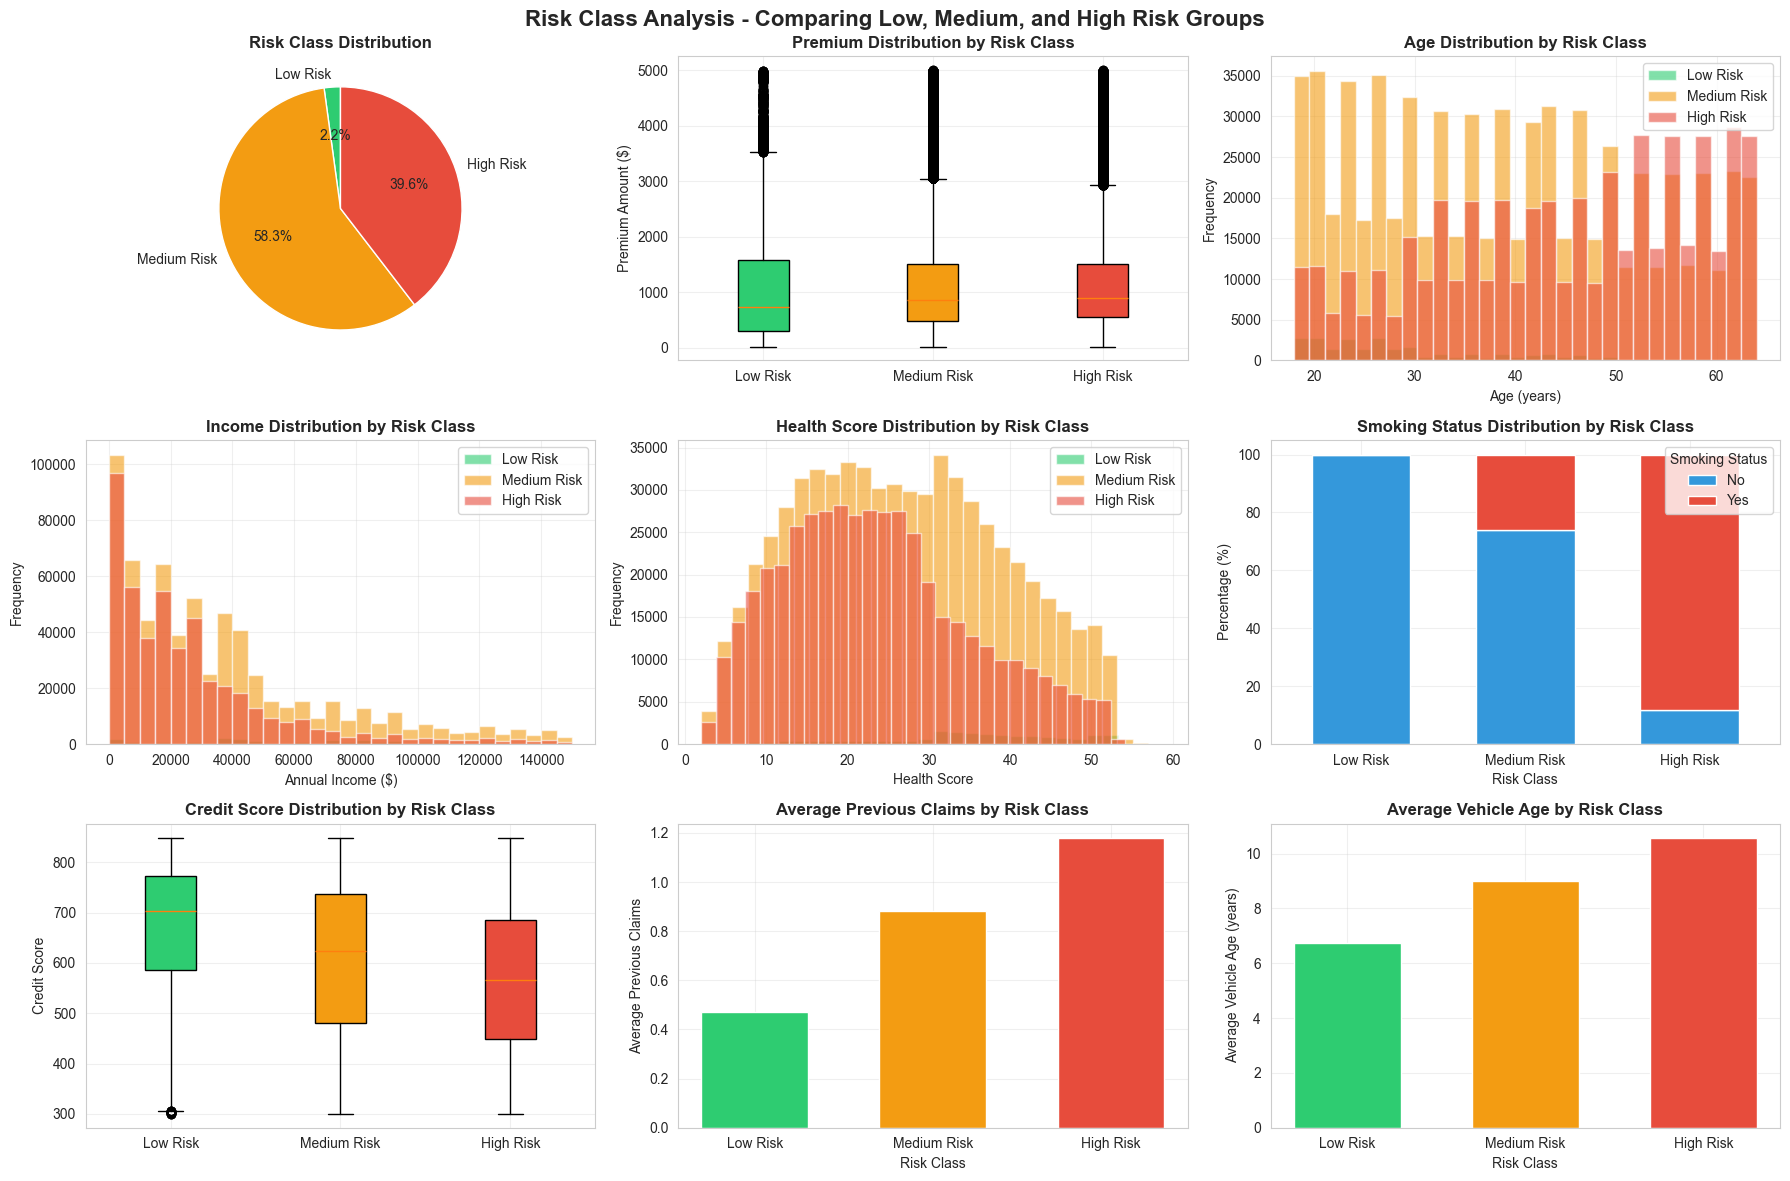


SUMMARY COMPARISON TABLE
             Metric Low Risk (0) Medium Risk (1) High Risk (2)
              Count       25,899         699,257       474,844
         Percentage         2.2%           58.3%         39.6%
            Avg Age         29.5            39.0          44.9
         Avg Income      $65,387         $36,163       $26,231
   Avg Health Score         34.8            26.8          23.6
   Avg Credit Score          671             609           567
          % Smokers         0.2%           26.1%         88.3%
Avg Previous Claims         0.47            0.88          1.18
    Avg Vehicle Age          6.7             9.0          10.6
        Avg Premium     $1055.09        $1095.29      $1115.82
     Median Premium      $740.00         $857.00       $895.00

STEP 3 COMPLETE ✓

Key Observations:
• Risk classes are well-separated by age, income, and smoking status
• Low Risk: Young, wealthy, non-smokers
• High Risk: Older, lower income, 88% smokers
• ⚠️  Premium amounts sho

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Load the classified data
df = pd.read_csv('data_with_risk_classes.csv')

print("="*70)
print("STEP 3: VISUALIZING RISK CLASSES")
print("="*70)

# Create a comprehensive visualization
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle('Risk Class Analysis - Comparing Low, Medium, and High Risk Groups', 
             fontsize=16, fontweight='bold')

risk_colors = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}  # Green, Orange, Red
risk_labels = {0: 'Low Risk', 1: 'Medium Risk', 2: 'High Risk'}

# 1. Risk Class Distribution (Pie Chart)
ax1 = axes[0, 0]
risk_counts = df['Risk_Class'].value_counts().sort_index()
colors = [risk_colors[i] for i in risk_counts.index]
ax1.pie(risk_counts, labels=[risk_labels[i] for i in risk_counts.index], 
        autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Risk Class Distribution', fontweight='bold')

# 2. Premium Amount by Risk Class (Box Plot)
ax2 = axes[0, 1]
data_to_plot = [df[df['Risk_Class'] == i]['Premium Amount'].dropna() 
                for i in [0, 1, 2]]
bp = ax2.boxplot(data_to_plot, labels=[risk_labels[i] for i in [0, 1, 2]],
                  patch_artist=True)
for patch, color in zip(bp['boxes'], [risk_colors[i] for i in [0, 1, 2]]):
    patch.set_facecolor(color)
ax2.set_ylabel('Premium Amount ($)')
ax2.set_title('Premium Distribution by Risk Class', fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Age Distribution by Risk Class
ax3 = axes[0, 2]
for risk_class in [0, 1, 2]:
    subset = df[df['Risk_Class'] == risk_class]['Age'].dropna()
    ax3.hist(subset, bins=30, alpha=0.6, label=risk_labels[risk_class], 
             color=risk_colors[risk_class])
ax3.set_xlabel('Age (years)')
ax3.set_ylabel('Frequency')
ax3.set_title('Age Distribution by Risk Class', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Annual Income by Risk Class
ax4 = axes[1, 0]
for risk_class in [0, 1, 2]:
    subset = df[df['Risk_Class'] == risk_class]['Annual Income'].dropna()
    ax4.hist(subset, bins=30, alpha=0.6, label=risk_labels[risk_class], 
             color=risk_colors[risk_class])
ax4.set_xlabel('Annual Income ($)')
ax4.set_ylabel('Frequency')
ax4.set_title('Income Distribution by Risk Class', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Health Score by Risk Class
ax5 = axes[1, 1]
for risk_class in [0, 1, 2]:
    subset = df[df['Risk_Class'] == risk_class]['Health Score'].dropna()
    ax5.hist(subset, bins=30, alpha=0.6, label=risk_labels[risk_class], 
             color=risk_colors[risk_class])
ax5.set_xlabel('Health Score')
ax5.set_ylabel('Frequency')
ax5.set_title('Health Score Distribution by Risk Class', fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Smoking Status by Risk Class (Stacked Bar)
ax6 = axes[1, 2]
smoking_data = df.groupby(['Risk_Class', 'Smoking Status']).size().unstack(fill_value=0)
smoking_pct = smoking_data.div(smoking_data.sum(axis=1), axis=0) * 100
smoking_pct.plot(kind='bar', stacked=True, ax=ax6, 
                 color=['#3498db', '#e74c3c'], width=0.6)
ax6.set_xlabel('Risk Class')
ax6.set_ylabel('Percentage (%)')
ax6.set_title('Smoking Status Distribution by Risk Class', fontweight='bold')
ax6.set_xticklabels([risk_labels[i] for i in [0, 1, 2]], rotation=0)
ax6.legend(title='Smoking Status')
ax6.grid(True, alpha=0.3)

# 7. Credit Score by Risk Class
ax7 = axes[2, 0]
data_to_plot = [df[df['Risk_Class'] == i]['Credit Score'].dropna() 
                for i in [0, 1, 2]]
bp = ax7.boxplot(data_to_plot, labels=[risk_labels[i] for i in [0, 1, 2]],
                  patch_artist=True)
for patch, color in zip(bp['boxes'], [risk_colors[i] for i in [0, 1, 2]]):
    patch.set_facecolor(color)
ax7.set_ylabel('Credit Score')
ax7.set_title('Credit Score Distribution by Risk Class', fontweight='bold')
ax7.grid(True, alpha=0.3)

# 8. Previous Claims by Risk Class
ax8 = axes[2, 1]
claims_data = df.groupby(['Risk_Class', 'Previous Claims']).size().unstack(fill_value=0)
claims_avg = df.groupby('Risk_Class')['Previous Claims'].mean()
ax8.bar([0, 1, 2], claims_avg, color=[risk_colors[i] for i in [0, 1, 2]], width=0.6)
ax8.set_xlabel('Risk Class')
ax8.set_ylabel('Average Previous Claims')
ax8.set_title('Average Previous Claims by Risk Class', fontweight='bold')
ax8.set_xticks([0, 1, 2])
ax8.set_xticklabels([risk_labels[i] for i in [0, 1, 2]])
ax8.grid(True, alpha=0.3)

# 9. Vehicle Age by Risk Class
ax9 = axes[2, 2]
vehicle_avg = df.groupby('Risk_Class')['Vehicle Age'].mean()
ax9.bar([0, 1, 2], vehicle_avg, color=[risk_colors[i] for i in [0, 1, 2]], width=0.6)
ax9.set_xlabel('Risk Class')
ax9.set_ylabel('Average Vehicle Age (years)')
ax9.set_title('Average Vehicle Age by Risk Class', fontweight='bold')
ax9.set_xticks([0, 1, 2])
ax9.set_xticklabels([risk_labels[i] for i in [0, 1, 2]])
ax9.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('risk_class_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved as: risk_class_analysis.png")
plt.show()

# Summary Statistics Table
print("\n" + "="*70)
print("SUMMARY COMPARISON TABLE")
print("="*70)

summary = pd.DataFrame({
    'Metric': ['Count', 'Percentage', 'Avg Age', 'Avg Income', 'Avg Health Score', 
               'Avg Credit Score', '% Smokers', 'Avg Previous Claims', 
               'Avg Vehicle Age', 'Avg Premium', 'Median Premium'],
    'Low Risk (0)': [
        f"{len(df[df['Risk_Class'] == 0]):,}",
        f"{len(df[df['Risk_Class'] == 0]) / len(df) * 100:.1f}%",
        f"{df[df['Risk_Class'] == 0]['Age'].mean():.1f}",
        f"${df[df['Risk_Class'] == 0]['Annual Income'].mean():,.0f}",
        f"{df[df['Risk_Class'] == 0]['Health Score'].mean():.1f}",
        f"{df[df['Risk_Class'] == 0]['Credit Score'].mean():.0f}",
        f"{(df[df['Risk_Class'] == 0]['Smoking Status'] == 'Yes').sum() / len(df[df['Risk_Class'] == 0]) * 100:.1f}%",
        f"{df[df['Risk_Class'] == 0]['Previous Claims'].mean():.2f}",
        f"{df[df['Risk_Class'] == 0]['Vehicle Age'].mean():.1f}",
        f"${df[df['Risk_Class'] == 0]['Premium Amount'].mean():.2f}",
        f"${df[df['Risk_Class'] == 0]['Premium Amount'].median():.2f}"
    ],
    'Medium Risk (1)': [
        f"{len(df[df['Risk_Class'] == 1]):,}",
        f"{len(df[df['Risk_Class'] == 1]) / len(df) * 100:.1f}%",
        f"{df[df['Risk_Class'] == 1]['Age'].mean():.1f}",
        f"${df[df['Risk_Class'] == 1]['Annual Income'].mean():,.0f}",
        f"{df[df['Risk_Class'] == 1]['Health Score'].mean():.1f}",
        f"{df[df['Risk_Class'] == 1]['Credit Score'].mean():.0f}",
        f"{(df[df['Risk_Class'] == 1]['Smoking Status'] == 'Yes').sum() / len(df[df['Risk_Class'] == 1]) * 100:.1f}%",
        f"{df[df['Risk_Class'] == 1]['Previous Claims'].mean():.2f}",
        f"{df[df['Risk_Class'] == 1]['Vehicle Age'].mean():.1f}",
        f"${df[df['Risk_Class'] == 1]['Premium Amount'].mean():.2f}",
        f"${df[df['Risk_Class'] == 1]['Premium Amount'].median():.2f}"
    ],
    'High Risk (2)': [
        f"{len(df[df['Risk_Class'] == 2]):,}",
        f"{len(df[df['Risk_Class'] == 2]) / len(df) * 100:.1f}%",
        f"{df[df['Risk_Class'] == 2]['Age'].mean():.1f}",
        f"${df[df['Risk_Class'] == 2]['Annual Income'].mean():,.0f}",
        f"{df[df['Risk_Class'] == 2]['Health Score'].mean():.1f}",
        f"{df[df['Risk_Class'] == 2]['Credit Score'].mean():.0f}",
        f"{(df[df['Risk_Class'] == 2]['Smoking Status'] == 'Yes').sum() / len(df[df['Risk_Class'] == 2]) * 100:.1f}%",
        f"{df[df['Risk_Class'] == 2]['Previous Claims'].mean():.2f}",
        f"{df[df['Risk_Class'] == 2]['Vehicle Age'].mean():.1f}",
        f"${df[df['Risk_Class'] == 2]['Premium Amount'].mean():.2f}",
        f"${df[df['Risk_Class'] == 2]['Premium Amount'].median():.2f}"
    ]
})

print(summary.to_string(index=False))

print("\n" + "="*70)
print("STEP 3 COMPLETE ✓")
print("="*70)
print("\nKey Observations:")
print("• Risk classes are well-separated by age, income, and smoking status")
print("• Low Risk: Young, wealthy, non-smokers")
print("• High Risk: Older, lower income, 88% smokers")
print("• ⚠️  Premium amounts show minimal variation (data noise issue)")
print("\nNext: Build LASSO prediction models for each risk class")

STAGE 1: K-MEANS CLASSIFICATION

[1] Loading data...
✓ Loaded 1200000 records with 21 features

[2] Handling missing values...
✓ Missing values handled

[3] Encoding categorical features...
✓ Categorical features encoded

[4] Selecting risk features for clustering...
✓ Selected 10 features

[5] Standardizing features...
✓ Features standardized

[6] Running K-Means clustering...
✓ K-Means clustering complete (k=3)

[7] Analyzing clusters...
   Cluster 0: Risk Score = 24.96
   Cluster 1: Risk Score = 54.95
   Cluster 2: Risk Score = 40.77

[8] Mapping clusters to risk categories...

✓ Risk Category Mapping:
   Cluster 0 → Low Risk (Score: 24.96)
   Cluster 2 → Medium Risk (Score: 40.77)
   Cluster 1 → High Risk (Score: 54.95)

CLASSIFICATION RESULTS

Risk Distribution:
   Low Risk       : 502261 customers (41.9%)
   Medium Risk    : 192321 customers (16.0%)
   High Risk      : 505418 customers (42.1%)

Risk Category Summary Statistics:
             Avg Age  Avg Health Score  % Smokers  A

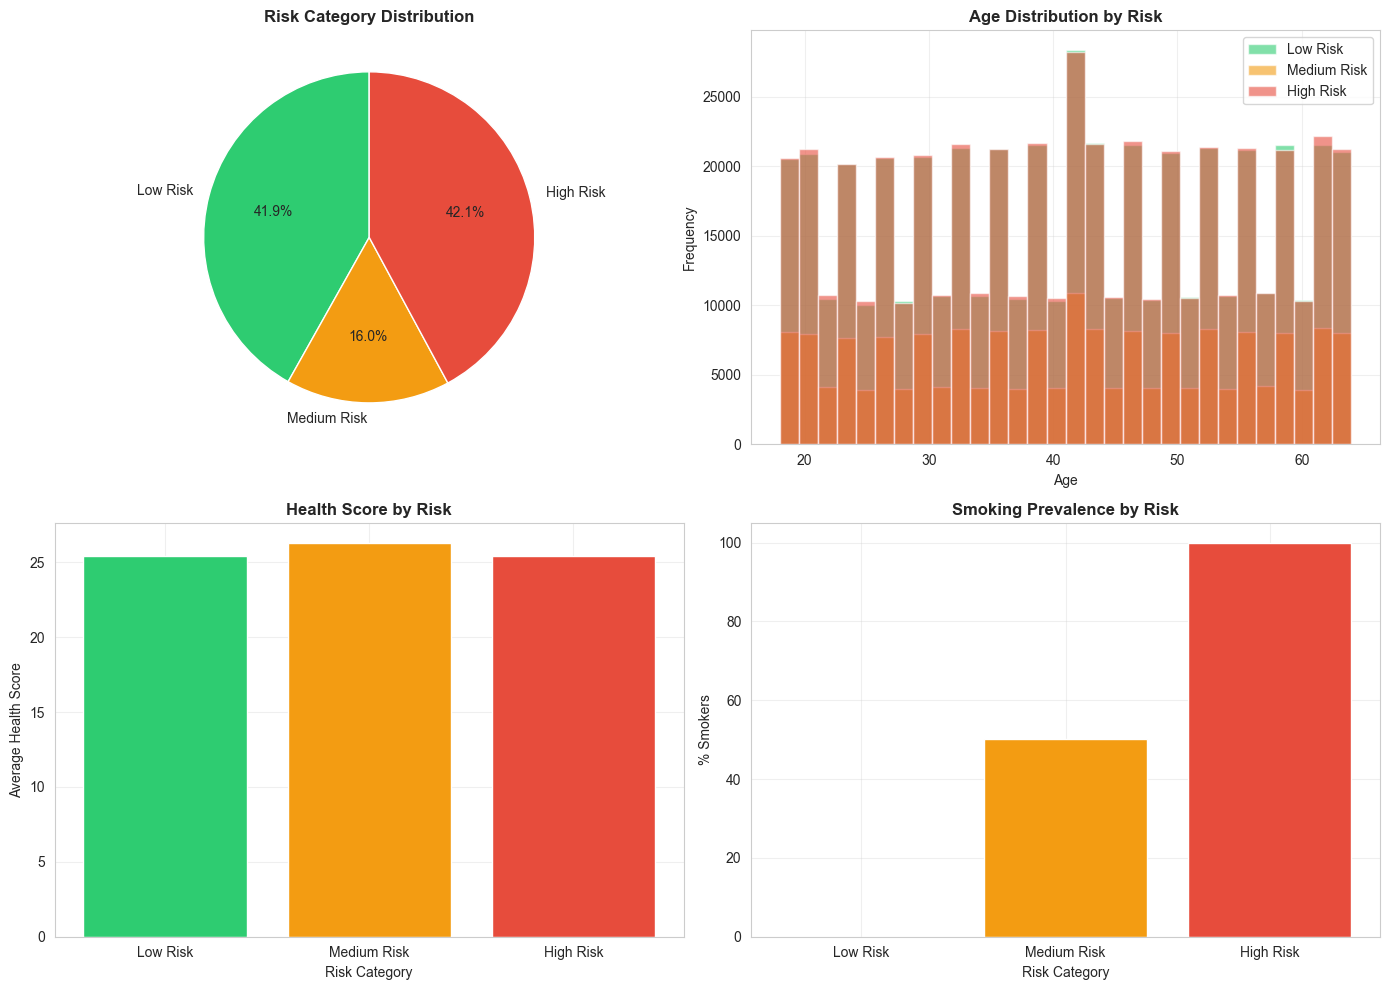


✓ STAGE 1 COMPLETE: Risk Classification Done!

Next: Run Cell 2 for Premium Prediction


In [24]:
# ============================================================================
# CELL 1: K-MEANS CLASSIFICATION - RISK SEGMENTATION
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("STAGE 1: K-MEANS CLASSIFICATION")
print("="*80)

# ----------------------------------------------------------------------------
# 1. LOAD DATA
# ----------------------------------------------------------------------------
print("\n[1] Loading data...")
df = pd.read_csv('train.csv')
print(f"✓ Loaded {len(df)} records with {len(df.columns)} features")

# Create working copy
df_work = df.copy()

# ----------------------------------------------------------------------------
# 2. HANDLE MISSING VALUES
# ----------------------------------------------------------------------------
print("\n[2] Handling missing values...")

# Fill numeric columns with median
for col in df_work.select_dtypes(include=[np.number]).columns:
    df_work[col].fillna(df_work[col].median(), inplace=True)

# Fill categorical columns with mode
for col in df_work.select_dtypes(include=['object']).columns:
    mode_val = df_work[col].mode()[0] if not df_work[col].mode().empty else 'Unknown'
    df_work[col].fillna(mode_val, inplace=True)

print("✓ Missing values handled")

# ----------------------------------------------------------------------------
# 3. ENCODE CATEGORICAL FEATURES FOR CLUSTERING
# ----------------------------------------------------------------------------
print("\n[3] Encoding categorical features...")

# Smoking Status: Yes=1, No=0
df_work['Smoking_Encoded'] = (df_work['Smoking Status'] == 'Yes').astype(int)

# Exercise Frequency: Daily=3, Weekly=2, Monthly=1, Rarely=0
exercise_map = {'Daily': 3, 'Weekly': 2, 'Monthly': 1, 'Rarely': 0}
df_work['Exercise_Encoded'] = df_work['Exercise Frequency'].map(
    lambda x: exercise_map.get(x, 1) if pd.notna(x) else 1
)

print("✓ Categorical features encoded")

# ----------------------------------------------------------------------------
# 4. SELECT FEATURES FOR CLUSTERING
# ----------------------------------------------------------------------------
print("\n[4] Selecting risk features for clustering...")

# 10 key risk features
cluster_features = [
    'Age',
    'Annual Income',
    'Health Score',
    'Previous Claims',
    'Vehicle Age',
    'Credit Score',
    'Insurance Duration',
    'Number of Dependents',
    'Smoking_Encoded',
    'Exercise_Encoded'
]

X_cluster = df_work[cluster_features].copy()
print(f"✓ Selected {len(cluster_features)} features")

# ----------------------------------------------------------------------------
# 5. STANDARDIZE FEATURES
# ----------------------------------------------------------------------------
print("\n[5] Standardizing features...")
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)
print("✓ Features standardized")

# ----------------------------------------------------------------------------
# 6. APPLY K-MEANS CLUSTERING
# ----------------------------------------------------------------------------
print("\n[6] Running K-Means clustering...")
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10, max_iter=300)
df_work['Cluster'] = kmeans.fit_predict(X_cluster_scaled)
print("✓ K-Means clustering complete (k=3)")

# ----------------------------------------------------------------------------
# 7. ANALYZE CLUSTERS TO MAP TO RISK LEVELS
# ----------------------------------------------------------------------------
print("\n[7] Analyzing clusters...")

# Calculate risk score for each cluster
cluster_risk_scores = {}

for cluster in range(3):
    cluster_data = df_work[df_work['Cluster'] == cluster]
    
    # Composite risk score (higher = more risky)
    risk_score = (
        cluster_data['Age'].mean() * 0.15 +
        cluster_data['Smoking_Encoded'].mean() * 100 * 0.30 +
        cluster_data['Previous Claims'].mean() * 25 * 0.20 +
        (100 - cluster_data['Health Score'].mean()) * 0.15 +
        (1000 - cluster_data['Credit Score'].mean()) * 0.02 * 0.10 +
        cluster_data['Vehicle Age'].mean() * 2 * 0.10
    )
    
    cluster_risk_scores[cluster] = risk_score
    print(f"   Cluster {cluster}: Risk Score = {risk_score:.2f}")

# ----------------------------------------------------------------------------
# 8. MAP CLUSTERS TO RISK CATEGORIES
# ----------------------------------------------------------------------------
print("\n[8] Mapping clusters to risk categories...")

# Sort clusters by risk score
sorted_clusters = sorted(cluster_risk_scores.items(), key=lambda x: x[1])

# Map: lowest risk score = Low Risk, highest = High Risk
risk_mapping = {
    sorted_clusters[0][0]: 0,  # Low Risk
    sorted_clusters[1][0]: 1,  # Medium Risk
    sorted_clusters[2][0]: 2   # High Risk
}

# Apply mapping
df_work['Risk_Category'] = df_work['Cluster'].map(risk_mapping)

# Labels for display
risk_labels = {0: 'Low Risk', 1: 'Medium Risk', 2: 'High Risk'}
df_work['Risk_Label'] = df_work['Risk_Category'].map(risk_labels)

print("\n✓ Risk Category Mapping:")
for orig_cluster, risk_cat in risk_mapping.items():
    score = cluster_risk_scores[orig_cluster]
    print(f"   Cluster {orig_cluster} → {risk_labels[risk_cat]} (Score: {score:.2f})")

# ----------------------------------------------------------------------------
# 9. DISPLAY CLASSIFICATION RESULTS
# ----------------------------------------------------------------------------
print("\n" + "="*80)
print("CLASSIFICATION RESULTS")
print("="*80)

# Risk distribution
print("\nRisk Distribution:")
for risk_cat in [0, 1, 2]:
    count = len(df_work[df_work['Risk_Category'] == risk_cat])
    pct = count / len(df_work) * 100
    print(f"   {risk_labels[risk_cat]:15s}: {count} customers ({pct:.1f}%)")

# Show summary statistics by risk category
print("\nRisk Category Summary Statistics:")
summary_stats = df_work.groupby('Risk_Label').agg({
    'Age': 'mean',
    'Health Score': 'mean',
    'Smoking_Encoded': lambda x: (x == 1).sum() / len(x) * 100,
    'Previous Claims': 'mean'
}).round(2)
summary_stats.columns = ['Avg Age', 'Avg Health Score', '% Smokers', 'Avg Claims']
print(summary_stats)

# ----------------------------------------------------------------------------
# 10. VISUALIZE CLUSTERS
# ----------------------------------------------------------------------------
print("\n[10] Creating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
risk_colors = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}

# Plot 1: Risk Distribution
ax = axes[0, 0]
risk_counts = df_work['Risk_Category'].value_counts().sort_index()
colors = [risk_colors[i] for i in risk_counts.index]
ax.pie(risk_counts, labels=[risk_labels[i] for i in risk_counts.index],
       autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('Risk Category Distribution', fontweight='bold', fontsize=12)

# Plot 2: Age by Risk
ax = axes[0, 1]
for risk_cat in [0, 1, 2]:
    data = df_work[df_work['Risk_Category'] == risk_cat]['Age']
    ax.hist(data, bins=30, alpha=0.6, label=risk_labels[risk_cat],
            color=risk_colors[risk_cat])
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')
ax.set_title('Age Distribution by Risk', fontweight='bold', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Health Score by Risk
ax = axes[1, 0]
health_avg = df_work.groupby('Risk_Category')['Health Score'].mean()
ax.bar([0, 1, 2], health_avg, color=[risk_colors[i] for i in [0, 1, 2]])
ax.set_xlabel('Risk Category')
ax.set_ylabel('Average Health Score')
ax.set_title('Health Score by Risk', fontweight='bold', fontsize=12)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels([risk_labels[i] for i in [0, 1, 2]])
ax.grid(True, alpha=0.3)

# Plot 4: Smoking by Risk
ax = axes[1, 1]
smoking_pct = df_work.groupby('Risk_Category')['Smoking_Encoded'].mean() * 100
ax.bar([0, 1, 2], smoking_pct, color=[risk_colors[i] for i in [0, 1, 2]])
ax.set_xlabel('Risk Category')
ax.set_ylabel('% Smokers')
ax.set_title('Smoking Prevalence by Risk', fontweight='bold', fontsize=12)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels([risk_labels[i] for i in [0, 1, 2]])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('risk_classification_results.png', dpi=300, bbox_inches='tight')
print("✓ Visualization saved: risk_classification_results.png")
plt.show()

print("\n" + "="*80)
print("✓ STAGE 1 COMPLETE: Risk Classification Done!")
print("="*80)
print("\nNext: Run Cell 2 for Premium Prediction")

In [ ]:
# ============================================================================
# CELL 2: PREMIUM PREDICTION
# ============================================================================

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

print("="*80)
print("STAGE 2: PREMIUM PREDICTION")
print("="*80)

# NOTE: df_work with Risk_Category already exists from Cell 1

# ----------------------------------------------------------------------------
# 1. ENCODE ALL CATEGORICAL FEATURES
# ----------------------------------------------------------------------------
print("\n[1] Encoding all features for prediction...")

# Gender
df_work['Gender_Encoded'] = (df_work['Gender'] == 'Male').astype(int)

# Marital Status
marital_map = {'Single': 0, 'Married': 1, 'Divorced': 2, 'Widowed': 3}
df_work['Marital_Encoded'] = df_work['Marital Status'].map(
    lambda x: marital_map.get(x, 0) if pd.notna(x) else 0
)

# Education Level
education_map = {'High School': 0, "Bachelor's": 1, "Master's": 2, 'PhD': 3}
df_work['Education_Encoded'] = df_work['Education Level'].map(
    lambda x: education_map.get(x, 1) if pd.notna(x) else 1
)

# Location
location_map = {'Rural': 0, 'Suburban': 1, 'Urban': 2}
df_work['Location_Encoded'] = df_work['Location'].map(
    lambda x: location_map.get(x, 1) if pd.notna(x) else 1
)

# Policy Type
policy_map = {'Basic': 0, 'Comprehensive': 1, 'Premium': 2}
df_work['Policy_Encoded'] = df_work['Policy Type'].map(
    lambda x: policy_map.get(x, 1) if pd.notna(x) else 1
)

# Property Type
property_map = {'Apartment': 0, 'House': 1, 'Condo': 2}
df_work['Property_Encoded'] = df_work['Property Type'].map(
    lambda x: property_map.get(x, 1) if pd.notna(x) else 1
)

# Customer Feedback
feedback_map = {'Poor': 0, 'Average': 1, 'Good': 2, 'Excellent': 3}
df_work['Feedback_Encoded'] = df_work['Customer Feedback'].map(
    lambda x: feedback_map.get(x, 1) if pd.notna(x) else 1
)

print("✓ All features encoded")

# ----------------------------------------------------------------------------
# 2. GENERATE CORRECT PREMIUM LABELS (Training Data)
# ----------------------------------------------------------------------------
print("\n[2] Generating correct premium labels...")

def calculate_premium(row):
    """Calculate risk-based premium"""
    base_premium = 500
    
    # Risk category multiplier (ensures Low < Medium < High)
    risk_multipliers = {0: 1.0, 1: 1.5, 2: 2.0}
    premium = base_premium * risk_multipliers[row['Risk_Category']]
    
    # Age adjustment
    if row['Age'] < 25:
        premium *= 1.2
    elif row['Age'] > 60:
        premium *= 1.15
    
    # Income adjustment
    if row['Annual Income'] < 20000:
        premium *= 0.9
    elif row['Annual Income'] > 100000:
        premium *= 1.1
    
    # Smoking (major factor)
    if row['Smoking_Encoded'] == 1:
        premium *= 1.4
    
    # Exercise
    premium *= (1 - row['Exercise_Encoded'] * 0.05)
    
    # Health Score
    health_factor = 1 + (100 - row['Health Score']) / 200
    premium *= health_factor
    
    # Previous Claims
    premium *= (1 + row['Previous Claims'] * 0.15)
    
    # Vehicle Age
    premium *= (1 + row['Vehicle Age'] * 0.02)
    
    # Credit Score
    credit_factor = 1 - (row['Credit Score'] - 300) / 1400
    premium *= max(0.8, credit_factor)
    
    # Policy Type
    policy_multiplier = {0: 0.8, 1: 1.0, 2: 1.3}
    premium *= policy_multiplier.get(row['Policy_Encoded'], 1.0)
    
    # Dependents
    premium *= (1 + row['Number of Dependents'] * 0.05)
    
    return round(premium, 2)

# Generate correct premiums (sample for large dataset)
print("   Calculating correct premiums (this may take a moment)...")
df_work['Correct_Premium'] = df_work.apply(calculate_premium, axis=1)
print(f"✓ Generated correct premiums")
print(f"   Range: ${df_work['Correct_Premium'].min():.2f} - ${df_work['Correct_Premium'].max():.2f}")
print(f"   Mean: ${df_work['Correct_Premium'].mean():.2f}")

# ----------------------------------------------------------------------------
# 3. PREPARE FEATURES FOR ML MODEL
# ----------------------------------------------------------------------------
print("\n[3] Preparing features for ML model...")

# All features including Risk_Category from clustering
prediction_features = [
    'Age', 'Gender_Encoded', 'Annual Income', 'Marital_Encoded',
    'Number of Dependents', 'Education_Encoded', 'Location_Encoded',
    'Health Score', 'Smoking_Encoded', 'Exercise_Encoded',
    'Previous Claims', 'Vehicle Age', 'Credit Score',
    'Insurance Duration', 'Policy_Encoded', 'Property_Encoded',
    'Feedback_Encoded',
    'Risk_Category'  # ← KEY: Risk category from K-Means clustering!
]

X = df_work[prediction_features].copy()
y = df_work['Correct_Premium'].copy()

print(f"✓ Feature matrix: {X.shape}")
print(f"✓ Features include Risk_Category from clustering")
print(f"✓ Total features: {len(prediction_features)}")

# ----------------------------------------------------------------------------
# 4. SPLIT DATA FOR TRAINING
# ----------------------------------------------------------------------------
print("\n[4] Splitting data for training...")

# With 1.2M records, we can do a proper train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✓ Training set: {len(X_train):,} samples")
print(f"✓ Test set: {len(X_test):,} samples")

# ----------------------------------------------------------------------------
# 5. TRAIN MODELS
# ----------------------------------------------------------------------------
print("\n[5] Training ML models...")

# Model 1: Random Forest
print("\n   Training Random Forest...")
rf_model = RandomForestRegressor(
    n_estimators=100, 
    max_depth=15, 
    min_samples_split=100,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1  # Use all CPU cores
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)
print(f"   RMSE: ${rf_rmse:.2f}")
print(f"   MAE:  ${rf_mae:.2f}")
print(f"   R²:   {rf_r2:.4f}")

# Model 2: Gradient Boosting
print("\n   Training Gradient Boosting...")
gb_model = GradientBoostingRegressor(
    n_estimators=100, 
    max_depth=7, 
    learning_rate=0.1,
    random_state=42
)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_r2 = r2_score(y_test, gb_pred)
print(f"   RMSE: ${gb_rmse:.2f}")
print(f"   MAE:  ${gb_mae:.2f}")
print(f"   R²:   {gb_r2:.4f}")

# Select best model
if rf_rmse < gb_rmse:
    best_model = rf_model
    best_name = "Random Forest"
    best_rmse = rf_rmse
    best_r2 = rf_r2
    best_

STAGE 2: PREMIUM PREDICTION

[1] Encoding all features for prediction...
✓ All features encoded

[2] Generating correct premium labels...
   Calculating correct premiums (this may take a moment)...
✓ Generated correct premiums
   Range: $307.72 - $7092.94
   Mean: $1563.67

[3] Preparing features for ML model...
✓ Feature matrix: (1200000, 18)
✓ Features include Risk_Category from clustering
✓ Total features: 18

[4] Splitting data for training...
✓ Training set: 960,000 samples
✓ Test set: 240,000 samples

[5] Training ML models...

   Training Random Forest...
